# CAPM and Fama-French models: empirical practice

**Financial Principles** — Dr. Linh Ha, Anton Makarov

Companion notebook to the CAPM and Fama-French lecture: beta estimation, two-pass tests, Roll's critique, and the three-factor model, all on Kenneth French's monthly data.

### What this notebook covers

By the end you should be able to:

1. estimate an asset's CAPM beta from a time-series regression and verify the covariance formula;
2. distinguish asset beta from the beta of an investor's complete portfolio;
3. run static and Fama-MacBeth two-pass tests of the question "does higher beta imply higher average return?";
4. reproduce the main statistical reason the empirical Security Market Line comes out too flat;
5. demonstrate Roll's critique by changing the market proxy;
6. reconstruct the SMB and HML factors from the six size/book-to-market portfolios;
7. estimate and interpret market, size, and value loadings in the Fama-French three-factor model.

The organization follows Bodie, Kane and Marcus (chapters 8-10 and 13) and Hull chapter 1, same as the lecture. Returns are monthly decimals throughout the calculations.

### Road map

| Part | Main question | Empirical tool |
|---|---|---|
| 1 | How sensitive is an asset to the market? | Security Characteristic Line regression |
| 2 | What is the beta of an investor? | Complete-portfolio construction |
| 3 | Do high-beta assets earn more? | Static two-pass regression |
| 4 | Is the result stable through time? | Rolling first pass + monthly Fama–MacBeth regressions |
| 5 | Why is the empirical SML often too flat? | Errors-in-variables simulation |
| 6 | What changes when the benchmark changes? | Roll/benchmark-proxy experiment |
| 7–8 | What do SMB and HML add? | Factor construction and FF3 regressions |

## Setup and data

In [ ]:
from __future__ import annotations

from io import BytesIO, StringIO
from pathlib import Path
from zipfile import ZipFile
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
from scipy import stats
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# -------------------------
# configuration
# -------------------------
DATA_MODE = "auto"          # "auto", "bundled", "live", or "synthetic"
ANALYSIS_START = pd.Timestamp("1963-07-01")
SELECTED_ASSET = "HiTec"    # one of the ten industry portfolios
ROLLING_WINDOW = 60          # months used in rolling first-pass regressions
RANDOM_SEED = 20260820

OFFICIAL_URLS = {
    "factors": "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip",
    "industries": "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/10_Industry_Portfolios_CSV.zip",
    "portfolios25": "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/25_Portfolios_5x5_CSV.zip",
    "portfolios6": "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/6_Portfolios_2x3_CSV.zip",
}

The loader looks for the bundled files in a local `data/` directory first. If they are missing it tries a live download from the Kenneth French Data Library, and if that fails too it falls back to a deterministic synthetic dataset so the notebook still runs end to end. The printout below says which source was actually used — check it before interpreting any numbers.

The bundled snapshots come from different vintages, which is why the analyses involving the 25 size/book-to-market portfolios end earlier than those using the factor and industry files.

In [2]:
def parse_first_monthly_table(text: str, marker: str | None = None) -> pd.DataFrame:
    """Parse the first six-digit monthly table in a Kenneth French CSV-like file."""
    lines = text.replace("\r\n", "\n").replace("\r", "\n").split("\n")
    start_search = 0

    if marker is not None:
        for line_number, line in enumerate(lines):
            if marker.lower() in line.lower():
                start_search = line_number + 1
                break

    header_index = None
    for line_number in range(start_search, len(lines)):
        line = lines[line_number]
        if line.lstrip().startswith(",") and len(line.split(",")) >= 2:
            header_index = line_number
            break

    if header_index is None:
        raise ValueError("Could not locate the monthly table header.")

    data_lines: list[str] = []
    for line in lines[header_index + 1:]:
        first_field = line.split(",", 1)[0].strip()
        if re.fullmatch(r"\d{6}", first_field):
            data_lines.append(line)
        elif data_lines:
            break

    if not data_lines:
        raise ValueError("Could not locate monthly observations.")

    frame = pd.read_csv(StringIO("\n".join([lines[header_index], *data_lines])))
    frame.rename(columns={frame.columns[0]: "Date"}, inplace=True)
    frame["Date"] = pd.to_datetime(frame["Date"].astype(str).str.strip(), format="%Y%m")
    frame.set_index("Date", inplace=True)
    frame.columns = [str(column).strip() for column in frame.columns]
    frame = frame.apply(pd.to_numeric, errors="coerce")
    frame = frame.replace([-99.99, -999, -99, -999.99], np.nan) / 100.0
    return frame.sort_index()


def parse_six_portfolios(text: str) -> pd.DataFrame:
    """Parse the six 2x3 size/book-to-market portfolios, with or without a header."""
    first_nonempty = next(line for line in text.splitlines() if line.strip())
    standard_names = [
        "Date", "Small Low", "Small Neutral", "Small High",
        "Big Low", "Big Neutral", "Big High",
    ]

    if re.match(r"^\s*\d{6}\s*,", first_nonempty):
        frame = pd.read_csv(StringIO(text), header=None, names=standard_names)
        frame["Date"] = pd.to_datetime(frame["Date"].astype(str), format="%Y%m")
        frame.set_index("Date", inplace=True)
        return frame.apply(pd.to_numeric, errors="coerce") / 100.0

    frame = parse_first_monthly_table(text, marker="Average Value Weighted Returns -- Monthly")
    if frame.shape[1] != 6:
        raise ValueError(f"Expected six 2x3 portfolios, found {frame.shape[1]} columns.")
    frame.columns = standard_names[1:]
    return frame


def fetch_zipped_csv_text(url: str, timeout: int = 30) -> str:
    """Download a Kenneth French ZIP and return the first CSV/TXT member as text."""
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    with ZipFile(BytesIO(response.content)) as archive:
        members = [name for name in archive.namelist() if name.lower().endswith((".csv", ".txt"))]
        if not members:
            members = archive.namelist()
        if not members:
            raise ValueError("The downloaded archive was empty.")
        raw = archive.read(members[0])
    try:
        return raw.decode("utf-8")
    except UnicodeDecodeError:
        return raw.decode("latin-1")


def find_local_file(filename: str) -> Path | None:
    candidates = [Path("data") / filename, Path.cwd() / filename]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

In [3]:
def make_synthetic_bundle(seed: int = RANDOM_SEED) -> dict[str, pd.DataFrame]:
    """Create a deterministic, realistic-looking fallback dataset."""
    rng = np.random.default_rng(seed)
    dates = pd.date_range("1963-07-01", "2024-12-01", freq="MS")
    n_months = len(dates)

    factor_means = np.array([0.0055, 0.0018, 0.0025])
    factor_cov = np.array([
        [0.045**2, 0.00025, -0.00010],
        [0.00025, 0.030**2, 0.00008],
        [-0.00010, 0.00008, 0.032**2],
    ])
    factor_draws = rng.multivariate_normal(factor_means, factor_cov, size=n_months)
    rf = np.clip(rng.normal(0.0020, 0.0012, n_months), -0.0010, 0.0080)
    factors = pd.DataFrame(factor_draws, index=dates, columns=["Mkt-RF", "SMB", "HML"])
    factors["RF"] = rf

    industry_names = ["NoDur", "Durbl", "Manuf", "Enrgy", "HiTec", "Telcm", "Shops", "Hlth", "Utils", "Other"]
    industry_loadings = np.array([
        [0.78, -0.10, 0.15], [1.25, 0.20, 0.30], [1.05, 0.02, 0.18],
        [0.86, -0.12, 0.50], [1.23, 0.20, -0.50], [0.78, -0.18, 0.15],
        [1.00, 0.08, -0.05], [0.82, -0.20, -0.28], [0.53, -0.20, 0.30],
        [1.10, 0.05, 0.40],
    ])
    industry_alpha = np.array([0.0015, -0.0005, 0.0002, 0.0010, 0.0003, 0.0001, 0.0010, 0.0015, 0.0010, -0.0002])
    industry_noise = rng.normal(0.0, 0.030, size=(n_months, len(industry_names)))
    industry_excess = industry_alpha + factor_draws @ industry_loadings.T + industry_noise
    industries = pd.DataFrame(industry_excess + rf[:, None], index=dates, columns=industry_names)

    portfolio_columns: list[str] = []
    portfolio_loadings: list[list[float]] = []
    for size in range(1, 6):
        for bm in range(1, 6):
            if size == 1 and bm == 1:
                name = "SMALL LoBM"
            elif size == 1 and bm == 5:
                name = "SMALL HiBM"
            elif size == 5 and bm == 1:
                name = "BIG LoBM"
            elif size == 5 and bm == 5:
                name = "BIG HiBM"
            else:
                name = f"ME{size} BM{bm}"
            portfolio_columns.append(name)
            beta = 1.20 - 0.06 * (size - 1) + 0.02 * (3 - bm)
            smb_loading = 1.00 - 0.38 * (size - 1)
            hml_loading = -0.80 + 0.40 * (bm - 1)
            portfolio_loadings.append([beta, smb_loading, hml_loading])

    portfolio_loadings_array = np.asarray(portfolio_loadings)
    portfolio_noise = rng.normal(0.0, 0.035, size=(n_months, 25))
    p25_excess = factor_draws @ portfolio_loadings_array.T + portfolio_noise
    portfolios25 = pd.DataFrame(p25_excess + rf[:, None], index=dates, columns=portfolio_columns)

    six_names = ["Small Low", "Small Neutral", "Small High", "Big Low", "Big Neutral", "Big High"]
    six_loadings = np.array([
        [1.15, 1.00, -0.80], [1.10, 1.00, 0.00], [1.05, 1.00, 0.80],
        [1.00, -0.20, -0.80], [0.95, -0.20, 0.00], [0.90, -0.20, 0.80],
    ])
    six_noise = rng.normal(0.0, 0.015, size=(n_months, 6))
    six_excess = factor_draws @ six_loadings.T + six_noise
    portfolios6 = pd.DataFrame(six_excess + rf[:, None], index=dates, columns=six_names)

    return {
        "factors": factors,
        "industries": industries,
        "portfolios25": portfolios25,
        "portfolios6": portfolios6,
    }


def load_data_bundle(mode: str = DATA_MODE) -> tuple[dict[str, pd.DataFrame], str]:
    mode = mode.lower()
    if mode not in {"auto", "bundled", "live", "synthetic"}:
        raise ValueError("DATA_MODE must be 'auto', 'bundled', 'live', or 'synthetic'.")

    local_names = {
        "factors": "F-F_Research_Data_Factors.CSV",
        "industries": "10_Industry_Portfolios.CSV",
        "portfolios25": "25_Portfolios_5x5.CSV",
        "portfolios6": "6_Portfolios_2x3.csv",
    }

    if mode in {"auto", "bundled"}:
        local_paths = {key: find_local_file(filename) for key, filename in local_names.items()}
        if all(path is not None for path in local_paths.values()):
            factors = parse_first_monthly_table(local_paths["factors"].read_text(errors="replace"))
            industries = parse_first_monthly_table(
                local_paths["industries"].read_text(errors="replace"),
                marker="Average Value Weighted Returns -- Monthly",
            )
            portfolios25 = parse_first_monthly_table(
                local_paths["portfolios25"].read_text(errors="replace"),
                marker="Average Value Weighted Returns -- Monthly",
            )
            portfolios6 = parse_six_portfolios(local_paths["portfolios6"].read_text(errors="replace"))
            bundle = {
                "factors": factors,
                "industries": industries,
                "portfolios25": portfolios25,
                "portfolios6": portfolios6,
            }
            return bundle, "bundled offline Kenneth French snapshots"
        if mode == "bundled":
            missing = [filename for key, filename in local_names.items() if local_paths[key] is None]
            raise FileNotFoundError(f"Bundled mode requested, but these files are missing: {missing}")

    if mode in {"auto", "live"}:
        try:
            factor_text = fetch_zipped_csv_text(OFFICIAL_URLS["factors"])
            industry_text = fetch_zipped_csv_text(OFFICIAL_URLS["industries"])
            p25_text = fetch_zipped_csv_text(OFFICIAL_URLS["portfolios25"])
            p6_text = fetch_zipped_csv_text(OFFICIAL_URLS["portfolios6"])
            bundle = {
                "factors": parse_first_monthly_table(factor_text),
                "industries": parse_first_monthly_table(industry_text, "Average Value Weighted Returns -- Monthly"),
                "portfolios25": parse_first_monthly_table(p25_text, "Average Value Weighted Returns -- Monthly"),
                "portfolios6": parse_six_portfolios(p6_text),
            }
            return bundle, "live Kenneth French Data Library download"
        except Exception as exc:
            if mode == "live":
                raise RuntimeError("Live data download failed.") from exc
            print(f"Live download unavailable ({type(exc).__name__}: {exc}). Using synthetic fallback.")

    return make_synthetic_bundle(), "deterministic synthetic fallback"

In [4]:
bundle, DATA_SOURCE = load_data_bundle()

factors = bundle["factors"].copy()
industries = bundle["industries"].copy()
portfolios25 = bundle["portfolios25"].copy()
portfolios6 = bundle["portfolios6"].copy()

# Normalize minor naming inconsistencies in raw files.
industries.columns = [column.replace(" ", "") for column in industries.columns]
for frame in (factors, industries, portfolios25, portfolios6):
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)
    frame.sort_index(inplace=True)

if SELECTED_ASSET not in industries.columns:
    SELECTED_ASSET = industries.columns[0]

summary_rows = []
for name, frame in {
    "Fama–French factors": factors,
    "10 industry portfolios": industries,
    "25 size/BM portfolios": portfolios25,
    "6 size/BM portfolios": portfolios6,
}.items():
    summary_rows.append({
        "Dataset": name,
        "Rows": len(frame),
        "Columns": frame.shape[1],
        "First month": frame.index.min().strftime("%Y-%m"),
        "Last month": frame.index.max().strftime("%Y-%m"),
    })

print(f"Data source used: {DATA_SOURCE}")
display(pd.DataFrame(summary_rows).set_index("Dataset"))

Data source used: bundled offline Kenneth French snapshots


,Rows,Columns,First month,Last month
Dataset,,,,
Fama–French factors,1174,4,1926-07,2024-04
10 industry portfolios,1171,10,1926-07,2024-01
25 size/BM portfolios,1119,25,1926-07,2019-09
6 size/BM portfolios,1130,6,1926-07,2020-08


A note on units: the raw French files are in percent and the loader divides by 100, so `0.01` means 1% per month. Means and alphas are annualized by multiplying by 12, volatilities by $\sqrt{12}$.

In [5]:
def fit_time_series_model(
    asset_return: pd.Series,
    factor_frame: pd.DataFrame,
    factor_columns: list[str],
    start: pd.Timestamp | str = ANALYSIS_START,
    hac_lags: int = 6,
):
    data = asset_return.rename("Asset return").to_frame().join(
        factor_frame[["RF", *factor_columns]], how="inner"
    ).loc[start:].dropna()
    excess_return = data["Asset return"] - data["RF"]
    regressors = sm.add_constant(data[factor_columns])
    model = sm.OLS(excess_return, regressors).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lags}
    )
    return model, data, excess_return


def first_pass_capm(
    asset_returns: pd.DataFrame,
    factor_frame: pd.DataFrame,
    start: pd.Timestamp | str = ANALYSIS_START,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    joined = asset_returns.join(factor_frame[["Mkt-RF", "RF"]], how="inner").loc[start:].dropna()
    rows = []
    for asset in asset_returns.columns:
        y = joined[asset] - joined["RF"]
        model = sm.OLS(y, sm.add_constant(joined[["Mkt-RF"]])).fit()
        rows.append({
            "Asset": asset,
            "alpha": model.params["const"],
            "beta": model.params["Mkt-RF"],
            "beta_se": model.bse["Mkt-RF"],
            "residual_sd": model.resid.std(ddof=1),
            "adjusted_R2": model.rsquared_adj,
            "mean_excess_return": y.mean(),
        })
    return pd.DataFrame(rows).set_index("Asset"), joined


def hac_mean_test(series: pd.Series, null: float = 0.0, maxlags: int = 6) -> dict[str, float]:
    clean = series.dropna().astype(float)
    model = sm.OLS(clean.to_numpy(), np.ones((len(clean), 1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": maxlags}
    )
    estimate = float(model.params[0])
    standard_error = float(model.bse[0])
    t_stat = (estimate - null) / standard_error
    p_value = 2 * stats.norm.sf(abs(t_stat))
    return {
        "estimate": estimate,
        "standard_error": standard_error,
        "t_stat": t_stat,
        "p_value": p_value,
        "observations": len(clean),
    }


def compare_capm_and_ff3(
    asset_returns: pd.DataFrame,
    factor_frame: pd.DataFrame,
    start: pd.Timestamp | str = ANALYSIS_START,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    joined = asset_returns.join(
        factor_frame[["Mkt-RF", "SMB", "HML", "RF"]], how="inner"
    ).loc[start:].dropna()
    rows = []
    for asset in asset_returns.columns:
        y = joined[asset] - joined["RF"]
        capm = sm.OLS(y, sm.add_constant(joined[["Mkt-RF"]])).fit()
        ff3 = sm.OLS(y, sm.add_constant(joined[["Mkt-RF", "SMB", "HML"]])).fit()
        rows.append({
            "Asset": asset,
            "CAPM alpha": capm.params["const"],
            "CAPM beta": capm.params["Mkt-RF"],
            "CAPM adjusted R2": capm.rsquared_adj,
            "FF3 alpha": ff3.params["const"],
            "FF3 market beta": ff3.params["Mkt-RF"],
            "FF3 SMB loading": ff3.params["SMB"],
            "FF3 HML loading": ff3.params["HML"],
            "FF3 adjusted R2": ff3.rsquared_adj,
            "CAPM residual SD": capm.resid.std(ddof=1),
            "FF3 residual SD": ff3.resid.std(ddof=1),
        })
    return pd.DataFrame(rows).set_index("Asset"), joined

## 1. Asset beta: the Security Characteristic Line

For asset or portfolio $i$, the CAPM time-series regression is

$$R_{i,t}-R_{f,t}=\alpha_i+\beta_i\bigl(R_{M,t}-R_{f,t}\bigr)+\varepsilon_{i,t}.$$

The slope is the market beta,

$$\beta_i=\frac{\operatorname{Cov}(R_i-R_f,\,R_M-R_f)}{\operatorname{Var}(R_M-R_f)},$$

and the intercept is Jensen's alpha relative to the chosen benchmark. A beta above one means above-average sensitivity to market movements; below one, a defensive exposure.

In [6]:
asset_model, asset_data, asset_excess = fit_time_series_model(
    industries[SELECTED_ASSET], factors, ["Mkt-RF"]
)

beta_from_covariance = asset_excess.cov(asset_data["Mkt-RF"]) / asset_data["Mkt-RF"].var()
market_premium_monthly = asset_data["Mkt-RF"].mean()
risk_free_monthly = asset_data["RF"].mean()
capm_required_return_monthly = risk_free_monthly + asset_model.params["Mkt-RF"] * market_premium_monthly

coefficient_table = pd.DataFrame({
    "Estimate": asset_model.params,
    "HAC standard error": asset_model.bse,
    "t-statistic": asset_model.tvalues,
    "p-value": asset_model.pvalues,
})
coefficient_table.index = ["Alpha (monthly)", "Market beta"]

display(Markdown(f"**Selected test asset: `{SELECTED_ASSET}`**  "))
display(coefficient_table.round(4))

diagnostics = pd.DataFrame({
    "Value": {
        "Beta from regression": asset_model.params["Mkt-RF"],
        "Beta from Cov/Var": beta_from_covariance,
        "Annualized alpha": 12 * asset_model.params["const"],
        "Annualized sample return": 12 * asset_data["Asset return"].mean(),
        "Annualized CAPM required return": 12 * capm_required_return_monthly,
        "Adjusted R-squared": asset_model.rsquared_adj,
        "Observations": int(asset_model.nobs),
    }
})
display(diagnostics.round(4))

**Selected test asset: `HiTec`**  

,Estimate,HAC standard error,t-statistic,p-value
Alpha (monthly),0.0002,0.0013,0.1652,0.8688
Market beta,1.2297,0.0438,28.0785,0.0000


,Value
Beta from regression,1.2297
Beta from Cov/Var,1.2297
Annualized alpha,0.0026
Annualized sample return,0.1300
Annualized CAPM required return,0.1274
Adjusted R-squared,0.7489
Observations,727.0000


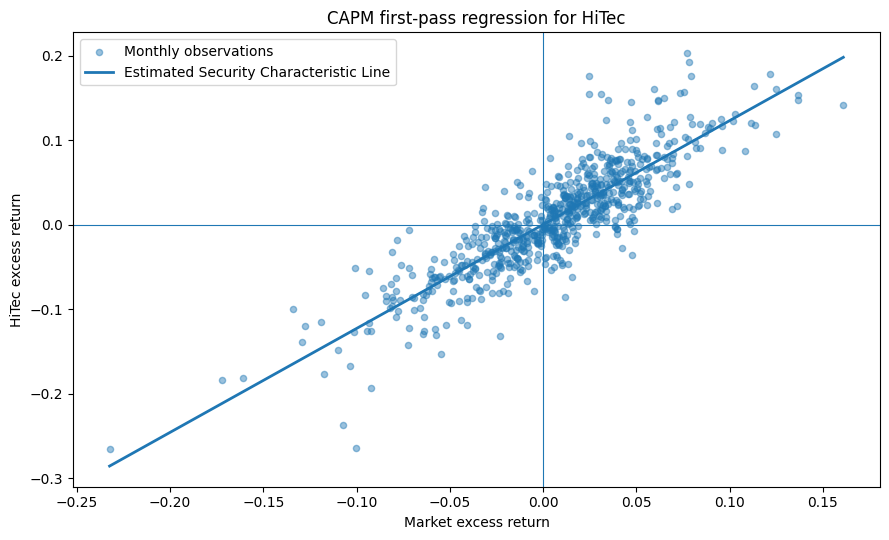

In [7]:
plt.figure(figsize=(9, 5.5))
plt.scatter(asset_data["Mkt-RF"], asset_excess, alpha=0.45, s=20, label="Monthly observations")
x_grid = np.linspace(asset_data["Mkt-RF"].min(), asset_data["Mkt-RF"].max(), 200)
y_grid = asset_model.params["const"] + asset_model.params["Mkt-RF"] * x_grid
plt.plot(x_grid, y_grid, linewidth=2, label="Estimated Security Characteristic Line")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Market excess return")
plt.ylabel(f"{SELECTED_ASSET} excess return")
plt.title(f"CAPM first-pass regression for {SELECTED_ASSET}")
plt.legend()
plt.tight_layout()
plt.show()

Beta captures the part of the asset's risk that moves with the market; the residual is idiosyncratic. In the CAPM, diversified investors are not compensated for the residual component: the required premium is proportional to beta alone.

## 2. Beta of an investor's complete portfolio

Under two-fund separation, an investor holds the risk-free asset and the market portfolio:

$$R_{C,t}=R_{f,t}+y\bigl(R_{M,t}-R_{f,t}\bigr).$$

Since $\beta_f=0$ and $\beta_M=1$, the complete-portfolio beta is simply $\beta_C=y$: differences in risk tolerance show up as different allocations to the same risky portfolio, not as different risky portfolios. A cautious investor has $0<y<1$, a fully invested one $y=1$, a leveraged one $y>1$.

In [8]:
investor_data = factors.loc[ANALYSIS_START:, ["Mkt-RF", "RF"]].dropna()
allocations = np.array([-0.5, 0.0, 0.5, 1.0, 1.5, 2.0])
investor_rows = []

for risky_weight in allocations:
    complete_return = investor_data["RF"] + risky_weight * investor_data["Mkt-RF"]
    model = sm.OLS(
        complete_return - investor_data["RF"],
        sm.add_constant(investor_data[["Mkt-RF"]]),
    ).fit()
    if risky_weight < 0:
        position = "Short market"
    elif risky_weight == 0:
        position = "Risk-free only"
    elif risky_weight < 1:
        position = "Lending / defensive"
    elif risky_weight == 1:
        position = "Market portfolio"
    else:
        position = "Borrowing / leveraged"
    investor_rows.append({
        "Risky-market weight y": risky_weight,
        "Position": position,
        "Theoretical beta": risky_weight,
        "Regression beta": model.params["Mkt-RF"],
        "Annualized mean return": 12 * complete_return.mean(),
        "Annualized volatility": np.sqrt(12) * complete_return.std(ddof=1),
    })

investor_beta_table = pd.DataFrame(investor_rows).set_index("Risky-market weight y")
display(investor_beta_table.round(4))

,Position,Theoretical beta,Regression beta,Annualized mean return,Annualized volatility
Risky-market weight y,,,,,
-0.5000,Short market,-0.5000,-0.5000,0.0094,0.0791
0.0000,Risk-free only,0.0000,0.0000,0.0436,0.0092
0.5000,Lending / defensive,0.5000,0.5000,0.0778,0.0776
1.0000,Market portfolio,1.0000,1.0000,0.1120,0.1551
1.5000,Borrowing / leveraged,1.5000,1.5000,0.1462,0.2329
2.0000,Borrowing / leveraged,2.0000,2.0000,0.1805,0.3107


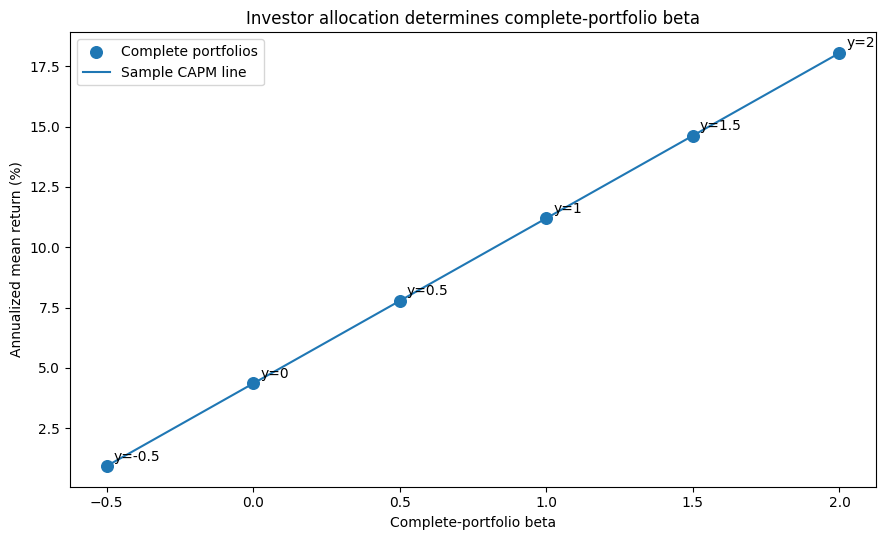

In [9]:
plt.figure(figsize=(9, 5.5))
plt.scatter(
    investor_beta_table["Regression beta"],
    100 * investor_beta_table["Annualized mean return"],
    s=70,
    label="Complete portfolios",
)
for risky_weight, row in investor_beta_table.iterrows():
    plt.annotate(f"y={risky_weight:g}", (row["Regression beta"], 100 * row["Annualized mean return"]), xytext=(5, 4), textcoords="offset points")

beta_grid = np.linspace(allocations.min(), allocations.max(), 200)
annual_rf = 12 * investor_data["RF"].mean()
annual_market_premium = 12 * investor_data["Mkt-RF"].mean()
plt.plot(beta_grid, 100 * (annual_rf + beta_grid * annual_market_premium), label="Sample CAPM line")
plt.xlabel("Complete-portfolio beta")
plt.ylabel("Annualized mean return (%)")
plt.title("Investor allocation determines complete-portfolio beta")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Static two-pass test of the CAPM

The textbook two-pass procedure separates beta estimation from the pricing test.

First pass, time series, one regression per asset:

$$R_{i,t}-R_{f,t}=\alpha_i+\beta_i(R_{M,t}-R_{f,t})+\varepsilon_{i,t}.$$

Second pass, cross section:

$$\overline{R_i-R_f}=\gamma_0+\gamma_1\widehat{\beta}_i+u_i.$$

The CAPM predicts $\gamma_0=0$ and $\gamma_1=\overline{R_M-R_f}$. So "higher beta means higher average return" is not just a positive slope — the slope has to equal the market risk premium. In the summary table below, the p-value in the market-premium row belongs to exactly that restriction, $\gamma_1=\overline{R_M-R_f}$.

In [10]:
first_pass_25, p25_capm_data = first_pass_capm(portfolios25, factors)
second_pass_model = sm.OLS(
    first_pass_25["mean_excess_return"],
    sm.add_constant(first_pass_25[["beta"]]),
).fit()

sample_market_premium = p25_capm_data["Mkt-RF"].mean()
slope_difference_t = (
    second_pass_model.params["beta"] - sample_market_premium
) / second_pass_model.bse["beta"]
slope_difference_p = 2 * stats.t.sf(abs(slope_difference_t), df=second_pass_model.df_resid)

static_test_summary = pd.DataFrame({
    "Estimate (annualized)": {
        "Second-pass intercept gamma0": 12 * second_pass_model.params["const"],
        "Second-pass slope gamma1": 12 * second_pass_model.params["beta"],
        "Sample market risk premium": 12 * sample_market_premium,
    },
    "Standard error / comparison": {
        "Second-pass intercept gamma0": 12 * second_pass_model.bse["const"],
        "Second-pass slope gamma1": 12 * second_pass_model.bse["beta"],
        "Sample market risk premium": np.nan,
    },
    "p-value": {
        "Second-pass intercept gamma0": second_pass_model.pvalues["const"],
        "Second-pass slope gamma1": second_pass_model.pvalues["beta"],
        "Sample market risk premium": slope_difference_p,
    },
})

print(
    f"Common sample: {p25_capm_data.index.min():%Y-%m} to {p25_capm_data.index.max():%Y-%m}; "
    f"beta range = {first_pass_25['beta'].min():.3f} to {first_pass_25['beta'].max():.3f}."
)
display(static_test_summary.round(4))

display(
    first_pass_25[["beta", "mean_excess_return", "residual_sd", "adjusted_R2"]]
    .sort_values("beta")
    .rename(columns={
        "mean_excess_return": "Mean monthly excess return",
        "residual_sd": "Residual SD",
        "adjusted_R2": "Adjusted R2",
    })
    .round(4)
)

Common sample: 1963-07 to 2019-09; beta range = 0.851 to 1.417.


,Estimate (annualized),Standard error / comparison,p-value
Second-pass intercept gamma0,0.1349,0.0345,0.0007
Second-pass slope gamma1,-0.0446,0.0315,0.1700
Sample market risk premium,0.0637,NaN,0.0022


,beta,Mean monthly excess return,Residual SD,Adjusted R2
Asset,,,,
ME5 BM3,0.8514,0.0055,0.0203,0.7729
ME5 BM4,0.8819,0.0049,0.0246,0.7123
ME5 BM2,0.9319,0.0054,0.0152,0.8789
ME4 BM4,0.9603,0.0083,0.0225,0.7779
ME3 BM4,0.9676,0.0086,0.0244,0.7520
BIG HiBM,0.9713,0.0065,0.0326,0.6311
BIG LoBM,0.9810,0.0052,0.0160,0.8791
ME3 BM3,1.0128,0.0075,0.0223,0.7983
ME4 BM3,1.0156,0.0070,0.0212,0.8152


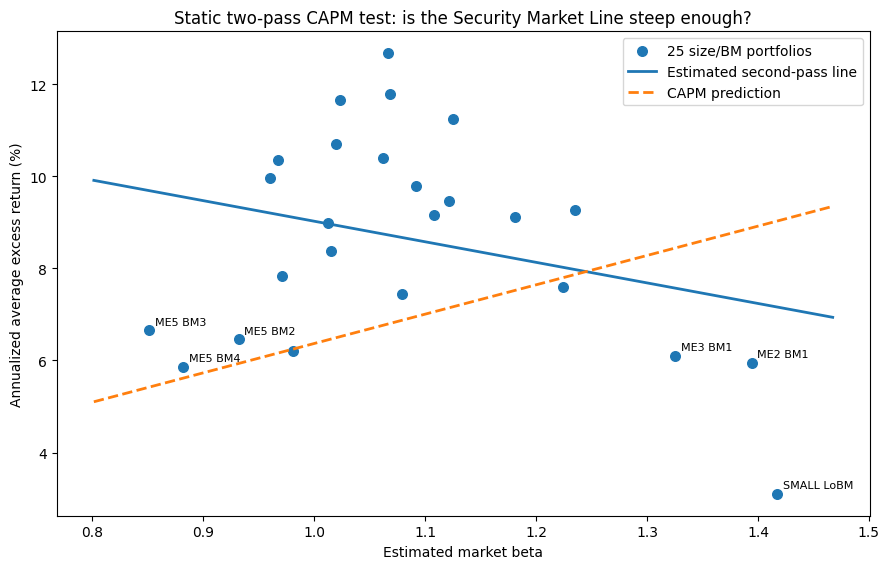

In [11]:
plt.figure(figsize=(9, 5.8))
annual_excess = 12 * first_pass_25["mean_excess_return"]
plt.scatter(first_pass_25["beta"], 100 * annual_excess, s=48, label="25 size/BM portfolios")

beta_grid = np.linspace(first_pass_25["beta"].min() - 0.05, first_pass_25["beta"].max() + 0.05, 200)
empirical_line = 12 * (second_pass_model.params["const"] + second_pass_model.params["beta"] * beta_grid)
theoretical_line = 12 * sample_market_premium * beta_grid
plt.plot(beta_grid, 100 * empirical_line, linewidth=2, label="Estimated second-pass line")
plt.plot(beta_grid, 100 * theoretical_line, linestyle="--", linewidth=2, label="CAPM prediction")

extreme_assets = pd.concat([
    first_pass_25.nsmallest(3, "beta"),
    first_pass_25.nlargest(3, "beta"),
]).drop_duplicates()
for asset, row in extreme_assets.iterrows():
    plt.annotate(asset, (row["beta"], 100 * 12 * row["mean_excess_return"]), xytext=(4, 4), textcoords="offset points", fontsize=8)

plt.xlabel("Estimated market beta")
plt.ylabel("Annualized average excess return (%)")
plt.title("Static two-pass CAPM test: is the Security Market Line steep enough?")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
expanded_regressors = first_pass_25[["beta", "residual_sd"]].copy()
expanded_regressors["beta_squared"] = expanded_regressors["beta"] ** 2
expanded_second_pass = sm.OLS(
    first_pass_25["mean_excess_return"],
    sm.add_constant(expanded_regressors[["beta", "beta_squared", "residual_sd"]]),
).fit()

expanded_table = pd.DataFrame({
    "Coefficient": expanded_second_pass.params,
    "Standard error": expanded_second_pass.bse,
    "t-statistic": expanded_second_pass.tvalues,
    "p-value": expanded_second_pass.pvalues,
})
expanded_table.index = ["Intercept", "Beta", "Beta squared", "Residual volatility"]
print("CAPM nulls: coefficient on beta squared = 0; coefficient on residual volatility = 0.")
display(expanded_table.round(4))

CAPM nulls: coefficient on beta squared = 0; coefficient on residual volatility = 0.


,Coefficient,Standard error,t-statistic,p-value
Intercept,-0.0594,0.0108,-5.5221,0.0000
Beta,0.1206,0.0191,6.3173,0.0000
Beta squared,-0.0563,0.0084,-6.7355,0.0000
Residual volatility,0.1158,0.0342,3.3889,0.0028


So, does high beta mean high return? Not in this sample: the second-pass slope is far flatter than the CAPM prediction and even comes out negative. Mind what this does and does not show — it is an empirical rejection for this benchmark and sample, not yet a logically decisive rejection of the theory. Section 6 explains why.

### Reducing estimation noise with beta-sorted portfolios

Black-Jensen-Scholes and Fama-MacBeth group securities into portfolios: diversification shrinks residual noise, and sorting on beta preserves cross-sectional dispersion. The price is fewer observations in the second pass.

The next cell estimates formation-period betas (1963-1989), sorts the 25 portfolios into five groups, and tests the beta-return relation out of sample from 1990 on.

In [13]:
FORMATION_END = pd.Timestamp("1989-12-01")
TEST_START = pd.Timestamp("1990-01-01")
BETA_GROUP_LABELS = ["Beta 1 (low)", "Beta 2", "Beta 3", "Beta 4", "Beta 5 (high)"]

formation_returns = portfolios25.loc[ANALYSIS_START:FORMATION_END]
formation_factors = factors.loc[:FORMATION_END]
formation_first_pass, _ = first_pass_capm(formation_returns, formation_factors)

beta_groups = pd.qcut(
    formation_first_pass["beta"].rank(method="first"),
    5,
    labels=BETA_GROUP_LABELS,
)

test_portfolios = pd.DataFrame({
    label: portfolios25.loc[TEST_START:, beta_groups[beta_groups == label].index].mean(axis=1)
    for label in BETA_GROUP_LABELS
})

test_first_pass, test_capm_data = first_pass_capm(
    test_portfolios, factors.loc[TEST_START:], start=TEST_START
)
test_second_pass = sm.OLS(
    test_first_pass["mean_excess_return"],
    sm.add_constant(test_first_pass[["beta"]]),
).fit()

beta_group_results = test_first_pass[["beta", "mean_excess_return", "residual_sd"]].copy()
beta_group_results["Annualized mean excess return"] = 12 * beta_group_results["mean_excess_return"]
beta_group_results["CAPM-predicted annual excess return"] = (
    12 * test_capm_data["Mkt-RF"].mean() * beta_group_results["beta"]
)

print(f"Formation period: {formation_returns.index.min():%Y-%m} to {formation_returns.index.max():%Y-%m}")
print(f"Test period: {test_capm_data.index.min():%Y-%m} to {test_capm_data.index.max():%Y-%m}")
display(pd.DataFrame({"Formation beta group": beta_groups}).sort_values("Formation beta group"))
display(beta_group_results.drop(columns="mean_excess_return").round(4))

Formation period: 1963-07 to 1989-12
Test period: 1990-01 to 2019-09


,Formation beta group
Asset,
BIG HiBM,Beta 1 (low)
ME5 BM3,Beta 1 (low)
ME4 BM4,Beta 1 (low)
ME3 BM4,Beta 1 (low)
ME5 BM4,Beta 1 (low)
ME5 BM2,Beta 2
BIG LoBM,Beta 2
ME4 BM3,Beta 2
ME3 BM3,Beta 2


,beta,residual_sd,Annualized mean excess return,CAPM-predicted annual excess return
Asset,,,,
Beta 1 (low),0.9539,0.0202,0.0851,0.0744
Beta 2,0.9695,0.0124,0.0919,0.0757
Beta 3,1.0312,0.0265,0.1090,0.0805
Beta 4,1.1016,0.0204,0.0987,0.0860
Beta 5 (high),1.2754,0.0358,0.0747,0.0995


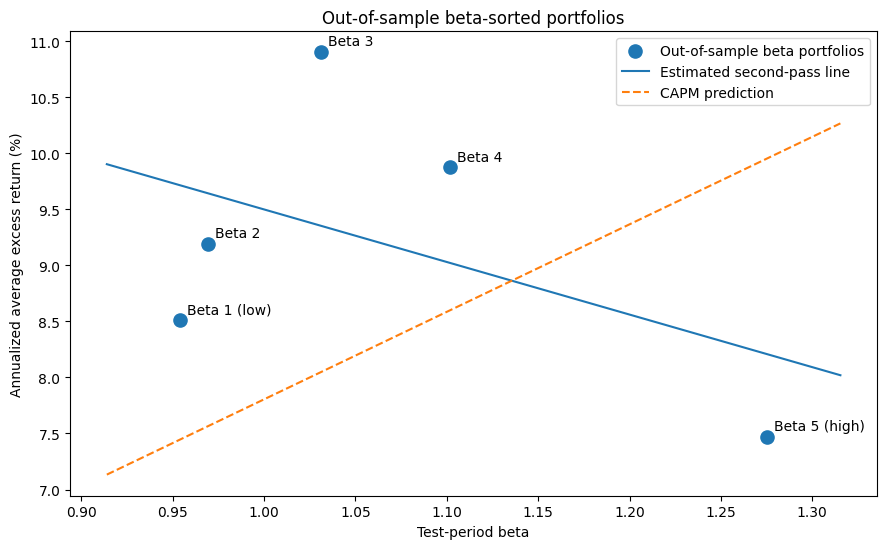

In [14]:
plt.figure(figsize=(9, 5.6))
plt.scatter(
    beta_group_results["beta"],
    100 * beta_group_results["Annualized mean excess return"],
    s=90,
    label="Out-of-sample beta portfolios",
)
for label, row in beta_group_results.iterrows():
    plt.annotate(label, (row["beta"], 100 * row["Annualized mean excess return"]), xytext=(5, 5), textcoords="offset points")

beta_grid = np.linspace(beta_group_results["beta"].min() - 0.04, beta_group_results["beta"].max() + 0.04, 200)
empirical = 12 * (test_second_pass.params["const"] + test_second_pass.params["beta"] * beta_grid)
theoretical = 12 * test_capm_data["Mkt-RF"].mean() * beta_grid
plt.plot(beta_grid, 100 * empirical, label="Estimated second-pass line")
plt.plot(beta_grid, 100 * theoretical, linestyle="--", label="CAPM prediction")
plt.xlabel("Test-period beta")
plt.ylabel("Annualized average excess return (%)")
plt.title("Out-of-sample beta-sorted portfolios")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Fama-MacBeth rolling two-pass test

The static test treats betas and average returns as fixed quantities. Fama-MacBeth instead repeats the exercise every month: estimate each portfolio's beta from a trailing window, regress the next month's returns on those betas, and use the time series of monthly slopes $\gamma_{1,t}$ for inference.

Below, a 60-month rolling first pass on the 25 size/book-to-market portfolios.

In [15]:
def fama_macbeth_capm(
    asset_returns: pd.DataFrame,
    factor_frame: pd.DataFrame,
    window: int = ROLLING_WINDOW,
    start: pd.Timestamp | str = ANALYSIS_START,
) -> pd.DataFrame:
    data = asset_returns.join(factor_frame[["Mkt-RF", "RF"]], how="inner").loc[start:].dropna()
    assets = list(asset_returns.columns)
    records = []

    for position in range(window, len(data)):
        history = data.iloc[position - window:position]
        market = history["Mkt-RF"].to_numpy()
        market_centered = market - market.mean()
        denominator = np.dot(market_centered, market_centered)

        excess_history = history[assets].sub(history["RF"], axis=0).to_numpy()
        excess_centered = excess_history - excess_history.mean(axis=0)
        beta_hat = (market_centered[:, None] * excess_centered).sum(axis=0) / denominator

        current_excess_return = data.iloc[position][assets].to_numpy(dtype=float) - float(data.iloc[position]["RF"])
        cross_section = sm.OLS(current_excess_return, sm.add_constant(beta_hat)).fit()

        records.append({
            "Date": data.index[position],
            "gamma0": cross_section.params[0],
            "gamma1": cross_section.params[1],
            "mean_beta": beta_hat.mean(),
            "beta_dispersion": beta_hat.std(ddof=1),
        })

    return pd.DataFrame(records).set_index("Date")


fm_coefficients = fama_macbeth_capm(portfolios25, factors)
fm_market_premium = factors.loc[fm_coefficients.index, "Mkt-RF"]

intercept_test = hac_mean_test(fm_coefficients["gamma0"])
slope_test = hac_mean_test(fm_coefficients["gamma1"])
slope_minus_market_test = hac_mean_test(fm_coefficients["gamma1"] - fm_market_premium)

fm_summary = pd.DataFrame({
    "Annualized estimate": {
        "Average gamma0": 12 * intercept_test["estimate"],
        "Average gamma1": 12 * slope_test["estimate"],
        "Average market premium": 12 * fm_market_premium.mean(),
        "Average gamma1 minus market premium": 12 * slope_minus_market_test["estimate"],
    },
    "Annualized HAC standard error": {
        "Average gamma0": 12 * intercept_test["standard_error"],
        "Average gamma1": 12 * slope_test["standard_error"],
        "Average market premium": np.nan,
        "Average gamma1 minus market premium": 12 * slope_minus_market_test["standard_error"],
    },
    "t-statistic": {
        "Average gamma0": intercept_test["t_stat"],
        "Average gamma1": slope_test["t_stat"],
        "Average market premium": np.nan,
        "Average gamma1 minus market premium": slope_minus_market_test["t_stat"],
    },
    "p-value": {
        "Average gamma0": intercept_test["p_value"],
        "Average gamma1": slope_test["p_value"],
        "Average market premium": np.nan,
        "Average gamma1 minus market premium": slope_minus_market_test["p_value"],
    },
})

print(f"Monthly cross-sectional regressions: {len(fm_coefficients)}")
display(fm_summary.round(4))

Monthly cross-sectional regressions: 615


,Annualized estimate,Annualized HAC standard error,t-statistic,p-value
Average gamma0,0.1203,0.0359,3.3484,0.0008
Average gamma1,-0.0395,0.0385,-1.0254,0.3052
Average market premium,0.0618,NaN,NaN,NaN
Average gamma1 minus market premium,-0.1013,0.0347,-2.9160,0.0035


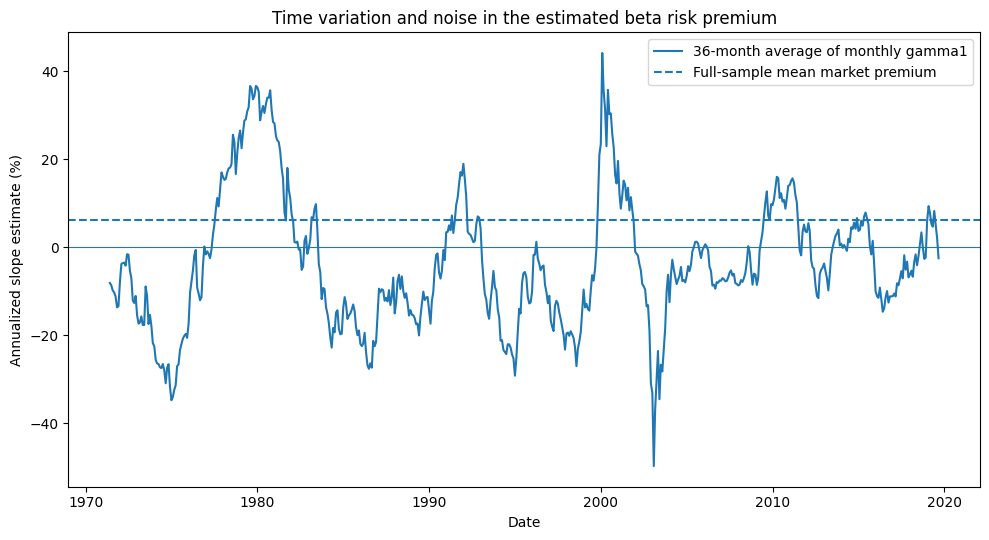

In [16]:
plt.figure(figsize=(10, 5.5))
rolling_gamma1 = 12 * fm_coefficients["gamma1"].rolling(36).mean()
plt.plot(rolling_gamma1.index, 100 * rolling_gamma1, label="36-month average of monthly gamma1")
plt.axhline(100 * 12 * fm_market_premium.mean(), linestyle="--", label="Full-sample mean market premium")
plt.axhline(0, linewidth=0.8)
plt.ylabel("Annualized slope estimate (%)")
plt.xlabel("Date")
plt.title("Time variation and noise in the estimated beta risk premium")
plt.legend()
plt.tight_layout()
plt.show()

A positive average $\gamma_1$ would support a positive beta-return relation; the sharper CAPM restriction is that it equals the market premium, with a zero intercept. Here the average slope is statistically indistinguishable from zero and reliably below the premium. The rolling plot shows how much the estimate moves around; short samples can support very different conclusions.

## 5. Why the estimated SML is too flat: measurement error in beta

The second-pass regressor is not the true beta, only a first-pass estimate. Classical errors-in-variables logic then says the second-pass slope is biased toward zero and the intercept is biased upward; longer estimation windows and diversified test portfolios reduce the problem.

The simulation below builds returns that satisfy the CAPM exactly, and still gets a flattened SML when the first-pass window is short.

In [17]:
def simulate_two_pass_measurement_error(
    n_replications: int = 500,
    n_assets: int = 100,
    n_months: int = 60,
    market_premium: float = 0.006,
    market_volatility: float = 0.045,
    residual_volatility: float = 0.09,
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed + n_months)
    true_beta = np.linspace(0.30, 1.80, n_assets)
    records = []

    for _ in range(n_replications):
        market = rng.normal(market_premium, market_volatility, n_months)
        residual = rng.normal(0.0, residual_volatility, size=(n_months, n_assets))
        asset_excess = market[:, None] * true_beta[None, :] + residual

        market_centered = market - market.mean()
        asset_centered = asset_excess - asset_excess.mean(axis=0)
        estimated_beta = (
            market_centered[:, None] * asset_centered
        ).sum(axis=0) / np.dot(market_centered, market_centered)

        average_returns = asset_excess.mean(axis=0)
        estimated_beta_regression = np.linalg.lstsq(
            np.column_stack([np.ones(n_assets), estimated_beta]),
            average_returns,
            rcond=None,
        )[0]
        true_beta_regression = np.linalg.lstsq(
            np.column_stack([np.ones(n_assets), true_beta]),
            average_returns,
            rcond=None,
        )[0]

        records.append({
            "Intercept using estimated beta": estimated_beta_regression[0],
            "Slope using estimated beta": estimated_beta_regression[1],
            "Slope using true beta": true_beta_regression[1],
        })

    return pd.DataFrame(records)


simulation_60 = simulate_two_pass_measurement_error(n_months=60)
simulation_240 = simulate_two_pass_measurement_error(n_months=240)
THEORETICAL_PREMIUM = 0.006

simulation_summary = pd.DataFrame({
    "60-month first pass": {
        "Mean intercept using estimated beta": 12 * simulation_60["Intercept using estimated beta"].mean(),
        "Mean slope using estimated beta": 12 * simulation_60["Slope using estimated beta"].mean(),
        "Mean slope using true beta": 12 * simulation_60["Slope using true beta"].mean(),
        "Theoretical market premium": 12 * THEORETICAL_PREMIUM,
    },
    "240-month first pass": {
        "Mean intercept using estimated beta": 12 * simulation_240["Intercept using estimated beta"].mean(),
        "Mean slope using estimated beta": 12 * simulation_240["Slope using estimated beta"].mean(),
        "Mean slope using true beta": 12 * simulation_240["Slope using true beta"].mean(),
        "Theoretical market premium": 12 * THEORETICAL_PREMIUM,
    },
})
display(simulation_summary.round(4))

,60-month first pass,240-month first pass
Mean intercept using estimated beta,0.0198,0.0055
Mean slope using estimated beta,0.0546,0.0655
Mean slope using true beta,0.0754,0.0709
Theoretical market premium,0.0720,0.0720


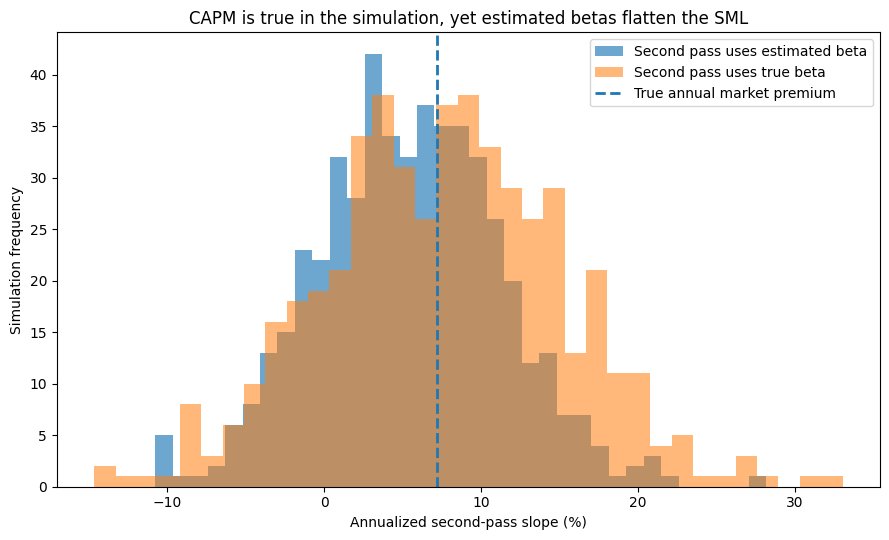

In [18]:
plt.figure(figsize=(9, 5.5))
plt.hist(100 * 12 * simulation_60["Slope using estimated beta"], bins=35, alpha=0.65, label="Second pass uses estimated beta")
plt.hist(100 * 12 * simulation_60["Slope using true beta"], bins=35, alpha=0.55, label="Second pass uses true beta")
plt.axvline(100 * 12 * THEORETICAL_PREMIUM, linestyle="--", linewidth=2, label="True annual market premium")
plt.xlabel("Annualized second-pass slope (%)")
plt.ylabel("Simulation frequency")
plt.title("CAPM is true in the simulation, yet estimated betas flatten the SML")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Roll's critique and the market portfolio

Roll's point of departure: the CAPM's one central testable implication is the mean-variance efficiency of the true market portfolio, which contains all assets, not just a stock index. Every empirical test uses a proxy. A rejection may only mean the proxy is inefficient; a non-rejection may mean the proxy happens to be efficient in this sample. Beta and alpha are benchmark-dependent objects.

The experiment: re-estimate every industry's beta and alpha against (1) the French market factor `Mkt-RF` and (2) an equal-weighted average of the ten industry portfolios.

In [19]:
proxy_data = industries.join(factors[["Mkt-RF", "RF"]], how="inner").loc[ANALYSIS_START:].dropna()
proxy_data["EW10-RF"] = proxy_data[industries.columns].mean(axis=1) - proxy_data["RF"]

proxy_rows = []
for asset in industries.columns:
    asset_excess_return = proxy_data[asset] - proxy_data["RF"]
    for proxy in ["Mkt-RF", "EW10-RF"]:
        model = sm.OLS(asset_excess_return, sm.add_constant(proxy_data[[proxy]])).fit()
        proxy_rows.append({
            "Asset": asset,
            "Proxy": proxy,
            "Alpha": model.params["const"],
            "Beta": model.params[proxy],
            "Adjusted R2": model.rsquared_adj,
        })

proxy_results = pd.DataFrame(proxy_rows)
proxy_beta = proxy_results.pivot(index="Asset", columns="Proxy", values="Beta")
proxy_alpha = 12 * proxy_results.pivot(index="Asset", columns="Proxy", values="Alpha")
proxy_comparison = pd.DataFrame({
    "Beta: official market": proxy_beta["Mkt-RF"],
    "Beta: EW industry proxy": proxy_beta["EW10-RF"],
    "Beta difference": proxy_beta["EW10-RF"] - proxy_beta["Mkt-RF"],
    "Annual alpha: official market": proxy_alpha["Mkt-RF"],
    "Annual alpha: EW industry proxy": proxy_alpha["EW10-RF"],
    "Annual alpha difference": proxy_alpha["EW10-RF"] - proxy_alpha["Mkt-RF"],
})

print(f"Correlation between the two market proxies: {proxy_data[['Mkt-RF', 'EW10-RF']].corr().iloc[0, 1]:.4f}")
display(proxy_comparison.round(4))

Correlation between the two market proxies: 0.9829


,Beta: official market,Beta: EW industry proxy,Beta difference,Annual alpha: official market,Annual alpha: EW industry proxy,Annual alpha difference
Asset,,,,,,
Durbl,1.2452,1.3679,0.1227,-0.0111,-0.0266,-0.0156
Enrgy,0.8631,0.9506,0.0875,0.0209,0.0100,-0.0110
HiTec,1.2297,1.2124,-0.0173,0.0026,-0.0026,-0.0052
Hlth,0.8209,0.8710,0.0501,0.0272,0.0192,-0.0080
Manuf,1.0382,1.0958,0.0576,0.0015,-0.0082,-0.0097
NoDur,0.7768,0.8517,0.0749,0.0258,0.0162,-0.0096
Other,1.0980,1.1565,0.0585,-0.0049,-0.0150,-0.0101
Shops,0.9987,1.0593,0.0606,0.0152,0.0055,-0.0097
Telcm,0.7761,0.8293,0.0532,0.0006,-0.0074,-0.0080


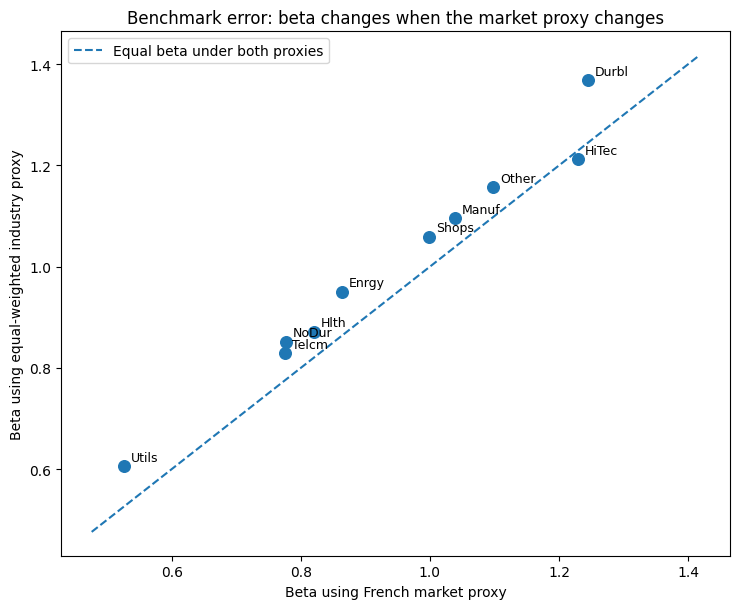

In [20]:
plt.figure(figsize=(7.5, 6.2))
plt.scatter(proxy_comparison["Beta: official market"], proxy_comparison["Beta: EW industry proxy"], s=70)
minimum_beta = proxy_comparison[["Beta: official market", "Beta: EW industry proxy"]].min().min() - 0.05
maximum_beta = proxy_comparison[["Beta: official market", "Beta: EW industry proxy"]].max().max() + 0.05
plt.plot([minimum_beta, maximum_beta], [minimum_beta, maximum_beta], linestyle="--", label="Equal beta under both proxies")
for asset, row in proxy_comparison.iterrows():
    plt.annotate(asset, (row["Beta: official market"], row["Beta: EW industry proxy"]), xytext=(5, 4), textcoords="offset points", fontsize=9)
plt.xlabel("Beta using French market proxy")
plt.ylabel("Beta using equal-weighted industry proxy")
plt.title("Benchmark error: beta changes when the market proxy changes")
plt.legend()
plt.tight_layout()
plt.show()

The two proxies correlate at 0.98 and still produce noticeably different betas and alphas — a manager with positive alpha under one benchmark can lose it under the other. Since the true market portfolio is unobservable, any CAPM test is a joint test of the model and the benchmark.

## 7. Constructing the Fama-French SMB and HML factors

The construction starts from six value-weighted portfolios, a 2×3 sort on size and book-to-market (Small/Big crossed with Low/Neutral/High). The zero-investment factors are

$$\text{SMB}=\tfrac{1}{3}(S/L+S/N+S/H)-\tfrac{1}{3}(B/L+B/N+B/H),$$

$$\text{HML}=\tfrac{1}{2}(S/H+B/H)-\tfrac{1}{2}(S/L+B/L).$$

SMB is long small and short big; HML is long value (high book-to-market) and short growth. Both are zero-net-investment long-short portfolios, so their return is already a premium and no risk-free rate gets subtracted.

In [21]:
reconstructed_factors = pd.DataFrame(index=portfolios6.index)
reconstructed_factors["SMB reconstructed"] = (
    portfolios6[["Small Low", "Small Neutral", "Small High"]].mean(axis=1)
    - portfolios6[["Big Low", "Big Neutral", "Big High"]].mean(axis=1)
)
reconstructed_factors["HML reconstructed"] = (
    0.5 * (portfolios6["Small High"] + portfolios6["Big High"])
    - 0.5 * (portfolios6["Small Low"] + portfolios6["Big Low"])
)
reconstructed_factors = reconstructed_factors.join(factors[["SMB", "HML"]], how="inner").dropna()

factor_construction_summary = pd.DataFrame({
    "SMB": {
        "Correlation with official factor": reconstructed_factors["SMB reconstructed"].corr(reconstructed_factors["SMB"]),
        "Mean absolute difference (monthly bps)": 10_000 * (reconstructed_factors["SMB reconstructed"] - reconstructed_factors["SMB"]).abs().mean(),
        "Mean reconstructed premium (annualized)": 12 * reconstructed_factors["SMB reconstructed"].mean(),
        "Mean official premium (annualized)": 12 * reconstructed_factors["SMB"].mean(),
    },
    "HML": {
        "Correlation with official factor": reconstructed_factors["HML reconstructed"].corr(reconstructed_factors["HML"]),
        "Mean absolute difference (monthly bps)": 10_000 * (reconstructed_factors["HML reconstructed"] - reconstructed_factors["HML"]).abs().mean(),
        "Mean reconstructed premium (annualized)": 12 * reconstructed_factors["HML reconstructed"].mean(),
        "Mean official premium (annualized)": 12 * reconstructed_factors["HML"].mean(),
    },
})

print(f"Comparison sample: {reconstructed_factors.index.min():%Y-%m} to {reconstructed_factors.index.max():%Y-%m}")
display(factor_construction_summary.round(4))

Comparison sample: 1926-07 to 2020-08


,SMB,HML
Correlation with official factor,0.9996,0.9993
Mean absolute difference (monthly bps),4.9990,7.8660
Mean reconstructed premium (annualized),0.0227,0.0389
Mean official premium (annualized),0.0228,0.0387


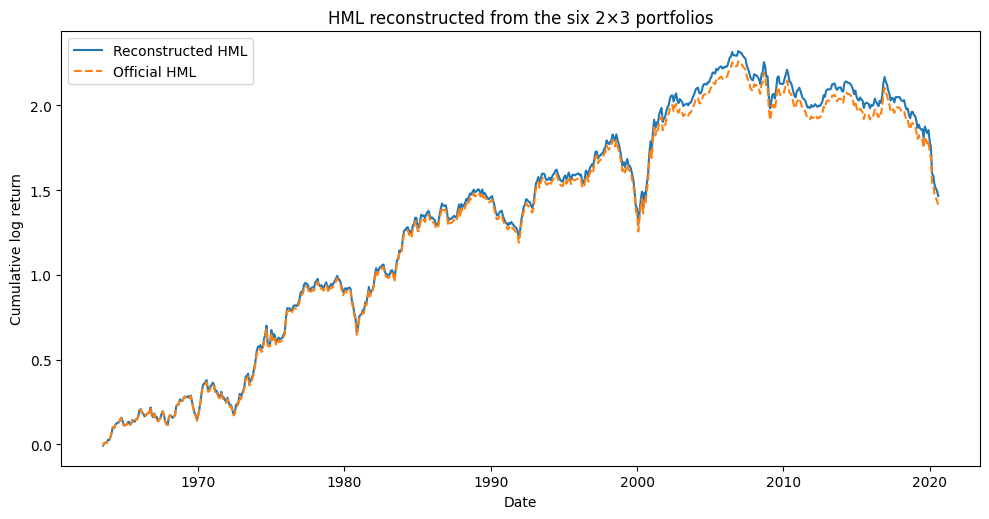

In [22]:
plot_start = max(ANALYSIS_START, reconstructed_factors.index.min())
log_cumulative_hml = np.log1p(reconstructed_factors.loc[plot_start:, ["HML reconstructed", "HML"]]).cumsum()
plt.figure(figsize=(10, 5.3))
plt.plot(log_cumulative_hml.index, log_cumulative_hml["HML reconstructed"], label="Reconstructed HML")
plt.plot(log_cumulative_hml.index, log_cumulative_hml["HML"], linestyle="--", label="Official HML")
plt.ylabel("Cumulative log return")
plt.xlabel("Date")
plt.title("HML reconstructed from the six 2×3 portfolios")
plt.legend()
plt.tight_layout()
plt.show()

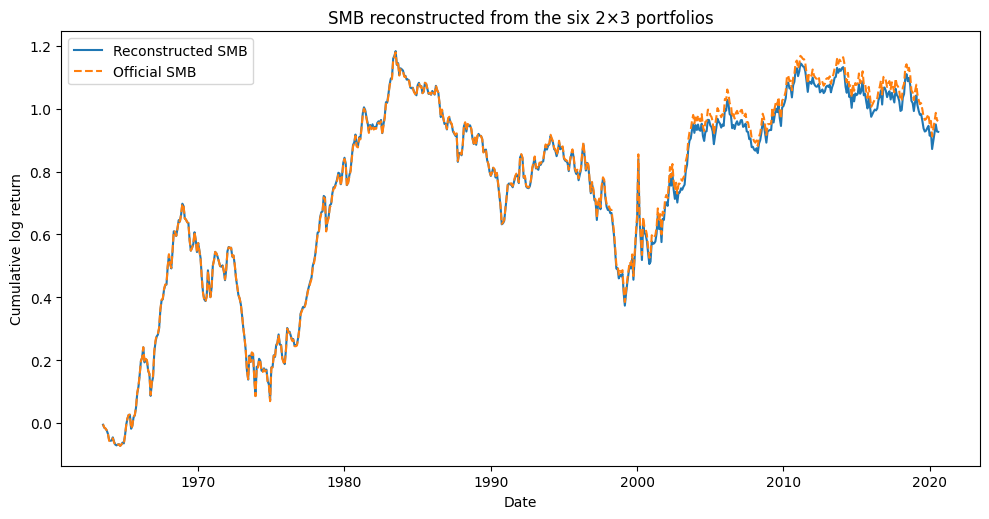

In [23]:
log_cumulative_smb = np.log1p(reconstructed_factors.loc[plot_start:, ["SMB reconstructed", "SMB"]]).cumsum()
plt.figure(figsize=(10, 5.3))
plt.plot(log_cumulative_smb.index, log_cumulative_smb["SMB reconstructed"], label="Reconstructed SMB")
plt.plot(log_cumulative_smb.index, log_cumulative_smb["SMB"], linestyle="--", label="Official SMB")
plt.ylabel("Cumulative log return")
plt.xlabel("Date")
plt.title("SMB reconstructed from the six 2×3 portfolios")
plt.legend()
plt.tight_layout()
plt.show()

Small discrepancies are expected here: the bundled files come from different vintages, and French's historical series get revised when CRSP data or the construction changes. Correlations this close to one are what "the formulas are right" looks like in practice.

## 8. Fama-French three-factor regressions

The time-series model is

$$R_{i,t}-R_{f,t}=\alpha_i+\beta_i(R_{M,t}-R_{f,t})+s_i\,SMB_t+h_i\,HML_t+\varepsilon_{i,t}.$$

A positive $s_i$ says the asset behaves like small stocks, a positive $h_i$ like value stocks, and $\alpha_i$ is whatever average return the three factors leave unexplained. Keep in mind the regression only measures exposures; it cannot tell whether SMB and HML reward risk or exploit persistent mispricing.

In [24]:
capm_selected, selected_capm_data, selected_excess = fit_time_series_model(
    industries[SELECTED_ASSET], factors, ["Mkt-RF"]
)
ff3_selected, selected_ff3_data, _ = fit_time_series_model(
    industries[SELECTED_ASSET], factors, ["Mkt-RF", "SMB", "HML"]
)

selected_model_comparison = pd.DataFrame({
    "CAPM": {
        "Annualized alpha": 12 * capm_selected.params["const"],
        "Market beta": capm_selected.params["Mkt-RF"],
        "SMB loading": np.nan,
        "HML loading": np.nan,
        "Adjusted R-squared": capm_selected.rsquared_adj,
        "Annualized residual volatility": np.sqrt(12) * capm_selected.resid.std(ddof=1),
    },
    "Fama–French 3": {
        "Annualized alpha": 12 * ff3_selected.params["const"],
        "Market beta": ff3_selected.params["Mkt-RF"],
        "SMB loading": ff3_selected.params["SMB"],
        "HML loading": ff3_selected.params["HML"],
        "Adjusted R-squared": ff3_selected.rsquared_adj,
        "Annualized residual volatility": np.sqrt(12) * ff3_selected.resid.std(ddof=1),
    },
})

display(Markdown(f"**Model comparison for `{SELECTED_ASSET}`**"))
display(selected_model_comparison.round(4))

ff3_inference = pd.DataFrame({
    "Estimate": ff3_selected.params,
    "HAC standard error": ff3_selected.bse,
    "t-statistic": ff3_selected.tvalues,
    "p-value": ff3_selected.pvalues,
})
ff3_inference.index = ["Alpha (monthly)", "Market beta", "SMB loading", "HML loading"]
display(ff3_inference.round(4))

**Model comparison for `HiTec`**

,CAPM,Fama–French 3
Annualized alpha,0.0026,0.0241
Market beta,1.2297,1.1205
SMB loading,NaN,0.1896
HML loading,NaN,-0.5202
Adjusted R-squared,0.7489,0.8173
Annualized residual volatility,0.1108,0.0943


,Estimate,HAC standard error,t-statistic,p-value
Alpha (monthly),0.0020,0.0010,1.9178,0.0551
Market beta,1.1205,0.0356,31.4441,0.0000
SMB loading,0.1896,0.0457,4.1505,0.0000
HML loading,-0.5202,0.0631,-8.2485,0.0000


,FF3 market beta,FF3 SMB loading,FF3 HML loading
Asset,,,
NoDur,0.8140,-0.0910,0.1400
Durbl,1.2520,0.1920,0.3300
Manuf,1.0590,0.0190,0.1800
Enrgy,0.9530,-0.1150,0.4850
HiTec,1.1200,0.1900,-0.5200
Telcm,0.8330,-0.1960,0.1310
Shops,0.9770,0.0860,-0.0300
Hlth,0.8230,-0.1960,-0.2730
Utils,0.6100,-0.2140,0.3000


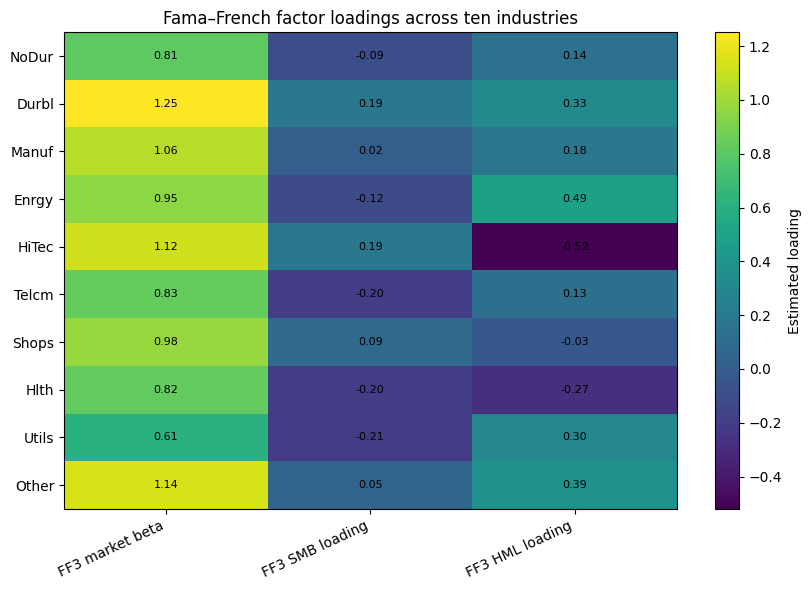

In [25]:
industry_model_comparison, industry_ff_data = compare_capm_and_ff3(industries, factors)
industry_loadings = industry_model_comparison[[
    "FF3 market beta", "FF3 SMB loading", "FF3 HML loading"
]]

display(industry_loadings.round(3))

plt.figure(figsize=(8.5, 6.0))
image = plt.imshow(industry_loadings.to_numpy(), aspect="auto")
plt.colorbar(image, label="Estimated loading")
plt.xticks(range(industry_loadings.shape[1]), industry_loadings.columns, rotation=25, ha="right")
plt.yticks(range(industry_loadings.shape[0]), industry_loadings.index)
for row in range(industry_loadings.shape[0]):
    for column in range(industry_loadings.shape[1]):
        plt.text(column, row, f"{industry_loadings.iloc[row, column]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Fama–French factor loadings across ten industries")
plt.tight_layout()
plt.show()

In [26]:
portfolio_model_comparison, p25_ff_data = compare_capm_and_ff3(portfolios25, factors)
factor_means = factors.loc[p25_ff_data.index, ["Mkt-RF", "SMB", "HML"]].mean()
actual_mean_excess = p25_ff_data[portfolios25.columns].sub(p25_ff_data["RF"], axis=0).mean()

capm_predicted_mean = portfolio_model_comparison["CAPM beta"] * factor_means["Mkt-RF"]
ff3_predicted_mean = (
    portfolio_model_comparison["FF3 market beta"] * factor_means["Mkt-RF"]
    + portfolio_model_comparison["FF3 SMB loading"] * factor_means["SMB"]
    + portfolio_model_comparison["FF3 HML loading"] * factor_means["HML"]
)

comparison_summary = pd.DataFrame({
    "CAPM": {
        "Mean absolute annualized alpha": 12 * portfolio_model_comparison["CAPM alpha"].abs().mean(),
        "Median adjusted R-squared": portfolio_model_comparison["CAPM adjusted R2"].median(),
        "Annualized pricing RMSE": 12 * np.sqrt(np.mean((actual_mean_excess - capm_predicted_mean) ** 2)),
        "Median annualized residual volatility": np.sqrt(12) * portfolio_model_comparison["CAPM residual SD"].median(),
    },
    "Fama–French 3": {
        "Mean absolute annualized alpha": 12 * portfolio_model_comparison["FF3 alpha"].abs().mean(),
        "Median adjusted R-squared": portfolio_model_comparison["FF3 adjusted R2"].median(),
        "Annualized pricing RMSE": 12 * np.sqrt(np.mean((actual_mean_excess - ff3_predicted_mean) ** 2)),
        "Median annualized residual volatility": np.sqrt(12) * portfolio_model_comparison["FF3 residual SD"].median(),
    },
})

print(f"25-portfolio comparison sample: {p25_ff_data.index.min():%Y-%m} to {p25_ff_data.index.max():%Y-%m}")
display(comparison_summary.round(4))

25-portfolio comparison sample: 1963-07 to 2019-09


,CAPM,Fama–French 3
Mean absolute annualized alpha,0.0265,0.0119
Median adjusted R-squared,0.7447,0.9151
Annualized pricing RMSE,0.0317,0.0167
Median annualized residual volatility,0.0947,0.0529


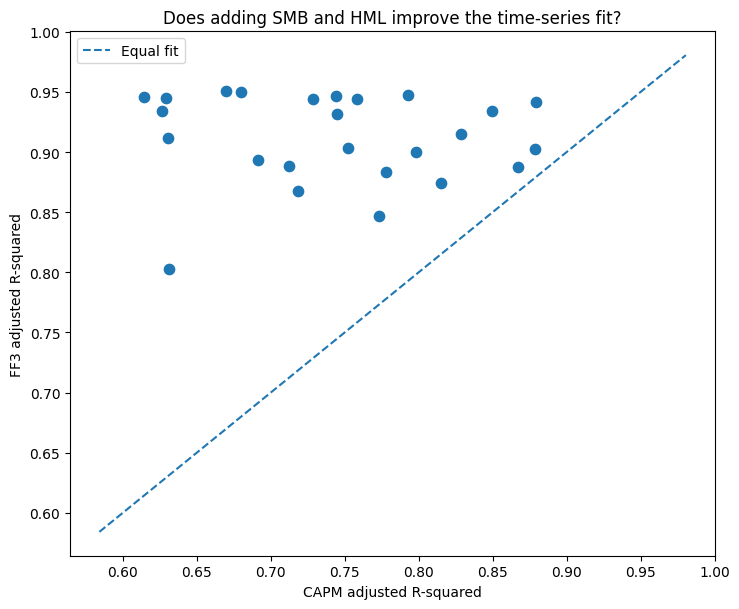

In [27]:
plt.figure(figsize=(7.5, 6.2))
plt.scatter(
    portfolio_model_comparison["CAPM adjusted R2"],
    portfolio_model_comparison["FF3 adjusted R2"],
    s=55,
)
minimum_r2 = min(
    portfolio_model_comparison["CAPM adjusted R2"].min(),
    portfolio_model_comparison["FF3 adjusted R2"].min(),
) - 0.03
maximum_r2 = max(
    portfolio_model_comparison["CAPM adjusted R2"].max(),
    portfolio_model_comparison["FF3 adjusted R2"].max(),
) + 0.03
plt.plot([minimum_r2, maximum_r2], [minimum_r2, maximum_r2], linestyle="--", label="Equal fit")
plt.xlabel("CAPM adjusted R-squared")
plt.ylabel("FF3 adjusted R-squared")
plt.title("Does adding SMB and HML improve the time-series fit?")
plt.legend()
plt.tight_layout()
plt.show()

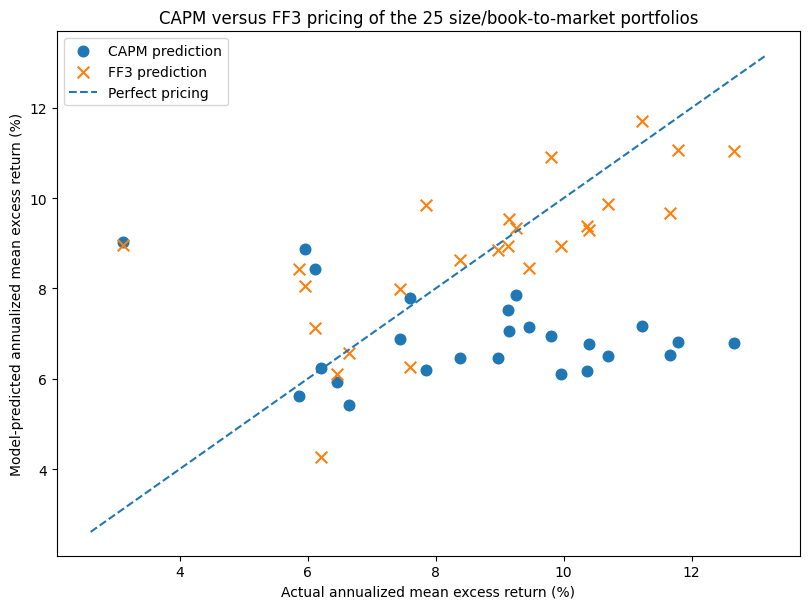

In [28]:
plt.figure(figsize=(8.2, 6.2))
plt.scatter(100 * 12 * actual_mean_excess, 100 * 12 * capm_predicted_mean, s=58, label="CAPM prediction")
plt.scatter(100 * 12 * actual_mean_excess, 100 * 12 * ff3_predicted_mean, marker="x", s=70, label="FF3 prediction")
axis_min = 100 * 12 * min(actual_mean_excess.min(), capm_predicted_mean.min(), ff3_predicted_mean.min()) - 0.5
axis_max = 100 * 12 * max(actual_mean_excess.max(), capm_predicted_mean.max(), ff3_predicted_mean.max()) + 0.5
plt.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", label="Perfect pricing")
plt.xlabel("Actual annualized mean excess return (%)")
plt.ylabel("Model-predicted annualized mean excess return (%)")
plt.title("CAPM versus FF3 pricing of the 25 size/book-to-market portfolios")
plt.legend()
plt.tight_layout()
plt.show()

For portfolios sorted on size and book-to-market, FF3 raises adjusted $R^2$, cuts residual volatility, and shrinks pricing errors — unsurprising, since these are exactly the spreads the extra factors were built to capture. For individual industries the improvement is smaller, and an alpha can even grow: see HiTec above, where the strongly negative HML loading raises the three-factor alpha.

## 9. Exercises

**Exercise 1 — another asset beta.** Change `SELECTED_ASSET` to `Enrgy`, `Utils`, or `Durbl`. Estimate beta by regression and by Cov/Var. What does the difference from one mean economically?

**Exercise 2 — portfolio beta.** Build a portfolio of 40% HiTec, 30% Utils and 30% Hlth. Compare (a) the regression beta of the portfolio with (b) the weighted average of the three individual betas.

**Exercise 3 — high beta, high return?** Move the formation/test split in the beta-sorted exercise. Does the slope become more positive or more negative? Is it anywhere near the market premium?

**Exercise 4 — Fama-MacBeth window.** Re-run the rolling test with 36, 60, and 120 months. How do the average slope and its standard error change?

**Exercise 5 — Roll's critique.** Build a third proxy from the five industries with the largest full-sample betas and re-estimate all alphas. Which assets switch classification most?

**Exercise 6 — growth versus value.** Compare `SMALL LoBM`, `SMALL HiBM`, `BIG LoBM`, and `BIG HiBM`. Which have positive SMB loadings? Positive HML loadings? Does FF3 reduce their CAPM alphas?

In [29]:
# Safe starter template: set RUN_STUDENT_TEMPLATE = True after filling the TODOs.
RUN_STUDENT_TEMPLATE = False

if RUN_STUDENT_TEMPLATE:
    # Exercise 2 skeleton
    exercise_weights = pd.Series({"HiTec": 0.40, "Utils": 0.30, "Hlth": 0.30})
    exercise_portfolio_return = industries[exercise_weights.index].mul(exercise_weights, axis=1).sum(axis=1)

    # TODO 1: estimate the regression beta of exercise_portfolio_return.
    # TODO 2: estimate each component beta and calculate their weighted average.
    # TODO 3: compare the two values and explain any small numerical discrepancy.
    pass
else:
    print("Student template is inactive. Set RUN_STUDENT_TEMPLATE = True after completing the TODOs.")

Student template is inactive. Set RUN_STUDENT_TEMPLATE = True after completing the TODOs.


<details>
<summary>Solution sketch for Exercise 2</summary>

```python
weights = pd.Series({"HiTec": 0.40, "Utils": 0.30, "Hlth": 0.30})
portfolio_return = industries[weights.index].mul(weights, axis=1).sum(axis=1)

portfolio_model, _, _ = fit_time_series_model(portfolio_return, factors, ["Mkt-RF"])
component_betas = {
    asset: fit_time_series_model(industries[asset], factors, ["Mkt-RF"])[0].params["Mkt-RF"]
    for asset in weights.index
}
weighted_beta = sum(weights[asset] * component_betas[asset] for asset in weights.index)

print("Regression beta:", portfolio_model.params["Mkt-RF"])
print("Weighted-average beta:", weighted_beta)
```

Beta is linear in portfolio weights, so the two numbers agree up to rounding and any differences in missing observations.
</details>

## 10. Key takeaways

1. Asset beta is a covariance ratio, estimated as the slope of asset excess returns on market excess returns.
2. The beta of an investor's complete portfolio is an allocation choice: under the CAPM it equals the fraction invested in the market.
3. The cross-sectional prediction is stronger than "beta and return are positively related" — the second-pass slope should equal the market premium, with a zero intercept.
4. Empirical SMLs come out too flat, and first-pass measurement error in beta mechanically attenuates the second-pass slope.
5. Roll's critique: every CAPM test is a joint test with the chosen market proxy, because the true market portfolio is unobservable.
6. SMB and HML can be rebuilt from six 2×3 portfolios as zero-investment long-short spreads.
7. FF3 improves fit and pricing for size/book-to-market portfolios — which by itself does not settle whether the factors reward risk or exploit mispricing.

### References and data

- Bodie, Z., A. Kane, and A. J. Marcus, *Investments*, chapters 8-10 and 13.
- Hull, J. C., *Risk Management and Financial Institutions*, chapter 1.
- Fama, E. F., and J. D. MacBeth (1973), "Risk, Return, and Equilibrium: Empirical Tests," *Journal of Political Economy* 81.
- Roll, R. (1977), "A Critique of the Asset Pricing Theory's Tests," *Journal of Financial Economics* 4.
- Fama, E. F., and K. R. French (1993), "Common Risk Factors in the Returns on Stocks and Bonds," *Journal of Financial Economics* 33.
- Factor and portfolio data: Kenneth R. French Data Library (bundled snapshots; set `DATA_MODE="live"` for the current versions).